# Societe Generale FX Trend Following

FX Timing indicators: Trend-Following strategies for the FX market

## Packages and Data

In [146]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from   matplotlib.ticker import FuncFormatter

In [5]:
writeup_path = os.getcwd()
res_path     = os.path.abspath(os.path.join(writeup_path, ".."))
repo_path    = os.path.abspath(os.path.join(res_path, ".."))
data_path    = os.path.join(repo_path, "data")
fut_path     = os.path.join(data_path, "FuturesData")

In [31]:
path      = os.path.join(data_path, "TickerGuide.xlsx")
contracts = ["AD", "BP", "CD", "EC", "JY", "NV", "PE", "SF"] 

df_tickers = (pd
    .read_excel(
        io         = path,
        sheet_name = "fut_guide")
    [["Tmp", "Root Contract", "Provider", "Front"]]
    .rename(columns = {
        "Tmp"          : "name",
        "Root Contract": "root",
        "Provider"     : "exchange",
        "Front"        : "front_contract"})
    .loc[lambda x: x.root.isin(contracts)]
    .assign(front_contract = lambda x: x.front_contract.str.lower().str.replace(" ", "_")))

In [44]:
path    = os.path.join(fut_path, "PrepFuturesPX.parquet")
tickers = df_tickers.front_contract.drop_duplicates().sort_values().to_list()

df_fx = (pd
    .read_parquet(path = path, engine = "pyarrow")
    .loc[lambda x: x.ticker.isin(tickers)]
    [["date", "ticker", "adj_val"]]
    .rename(columns = {"ticker": "front_contract"})
    .merge(right = df_tickers, how = "inner", on = ["front_contract"]))

## FX Timing Indicators: Trend-Following Strateiges for the FX Market

The main approach is to use a Taylor-Series decomposition of returns for some $S(t)$ as price centered around some price $a$
\begin{align}
S(t) &= \sum_{n = 0}^\infty \frac{S^{(n)}(a)}{n!} (x-a)^n\\
     &= S(t) + \frac{S'(a)}{1!}(x-a) + \frac{S''(a)}{2!} (x-a)^2 + \underbrace{\sum_{n=2}^\infty \frac{S^{(n)}(a)}{n!}(x-a)^n}_{\text{Higher order Noise}} 
\end{align}

These can be *easily approximated* by using moving averages of price and then taking the differences as *derivatives*
\begin{align}
MA(t,M) = \frac{1}{M+1}\sum_{i=0}^N S_{t-i}
\tag{1}
\end{align}
Then the daily differences are
\begin{align}
\Delta MA(t,M) &= MA(t,M) - MA(t-1,M)) \\
               &= \frac{1}{M+1} (S_t - S_{t-M-1})
\tag{2}
\end{align}

Now smooth equation 2 for the second derivative
\begin{align}
D(t,N,M) &= \frac{1}{N+1} \sum_{t=0}^N \Delta MA(t,M) \\
         &= \frac{1}{(N+1)(M+1)} \sum_{i=0}^N (S_{t-1} - S_{t-i-M-1})
\tag{3}
\end{align}
Then difference that
\begin{align}
\Delta D(t,N,M) &= D(t,N,M) - D(t-1,N,M) \\
                &= \frac{1}{(N+1)(M+1)}\sum_{i=0}^N (S_t - S_{t-M-N-2} - S_{t-N-1} - S_{t-M-1})
\tag{4}
\end{align}

The equation $2$ and $4$ are proxies for trend of the first and second derivatives. The signal will take a position corresponding to the sign when both equations have the same sign. The authors use a couple of parameters and since there are 2 parameters the number of permutations for a set can be quite large. To keep things conservative 20 days will be used for both and applied across all FX futures.

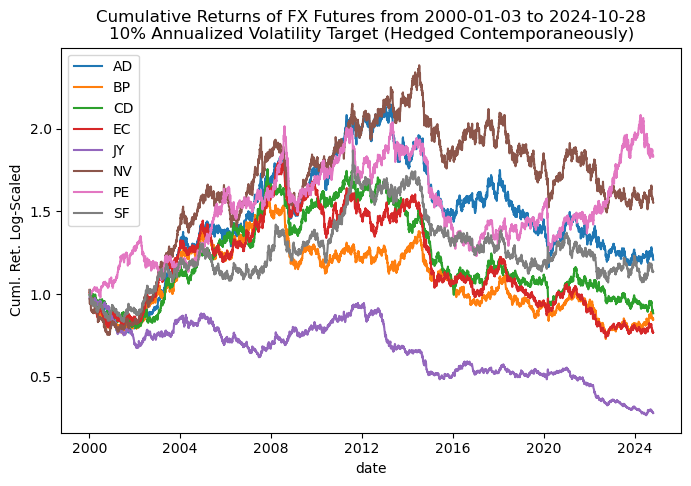

In [57]:
(df_fx
    .rename(columns = {"root": ""})
    .pivot(index = "date", columns = "", values = "adj_val")
    .pct_change()
    .apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252))))
    .apply(lambda x: np.cumprod(1 + x))
    .plot(
        figsize = (8,5),
        ylabel  = "Cuml. Ret. Log-Scaled",
        title   = "Cumulative Returns of FX Futures from {} to {}\n10% Annualized Volatility Target (Hedged Contemporaneously)".format(
            df_fx.date.min(),
            df_fx.date.max())))

plt.show()

Now compute the signal. I want to test for convexity and since the authors *pressumably* use a binary signal we'll keep with the taylor series and use $\frac{1}{2}$ of the second derivative. 

In [98]:
df_rtn = (df_fx
    .set_index("date")
    [["root", "adj_val"]]
    .groupby("root")
    .apply(lambda x: x.sort_index().adj_val.pct_change())
    .reset_index()
    .rename(columns = {"adj_val": "rtn"}))

In [168]:
M = 30
N = M

df_first = (df_fx
    .pivot(index = "date", columns = "root", values = "adj_val")
    .apply(lambda x: x.rolling(window = M).mean())
    .diff())

df_second = (df_first
    .apply(lambda x: x.rolling(window = N).mean())
    .diff())

In [169]:
df_first_longer = (df_first
    .reset_index()
    .melt(id_vars = "date", value_name = "first_div"))

df_second_longer = (df_second
    .reset_index()
    .melt(id_vars = "date", value_name = "second_div"))

In [170]:
def _lag_signal(df: pd.DataFrame) -> pd.DataFrame: 
    return df.sort_index().assign(lag_signal = lambda x: x.signal.shift())

df_signal = (df_first_longer
    .merge(right = df_second_longer, how = "inner", on = ["date", "root"])
    .dropna()
    .assign(
        mult_sig = lambda x: x.first_div * x.second_div,
        signal   = lambda x: np.where(x.mult_sig > 0, x.first_div + (0.5 * x.second_div), 0))
    .set_index("date")
    .groupby("root")
    .apply(_lag_signal)
    .reset_index())

In [171]:
df_signal_rtn = (df_signal
    .merge(right = df_rtn, how = "inner", on = ["date", "root"])
    .assign(signal_rtn = lambda x: x.lag_signal * x.rtn))

In [172]:
df_vol_rtn = (df_signal_rtn
    .pivot(index = "date", columns = "root", values = "signal_rtn")
    .apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252))))
    .reset_index()
    .melt(id_vars = "date", value_name = "vol_rtn")
    .dropna())

In [173]:
df_cuml = (df_vol_rtn
    .set_index("date")
    .groupby("root")
    .apply(lambda x: x.sort_index().vol_rtn.rolling(window = M//2).sum())
    .reset_index()
    .rename(columns = {"vol_rtn": "cuml_rtn"})
    .dropna())

In [174]:
df_combined = (df_signal_rtn
    .merge(right = df_vol_rtn, how = "inner", on = ["date", "root"])
    .merge(right = df_cuml, how = "inner", on = ["date", "root"]))

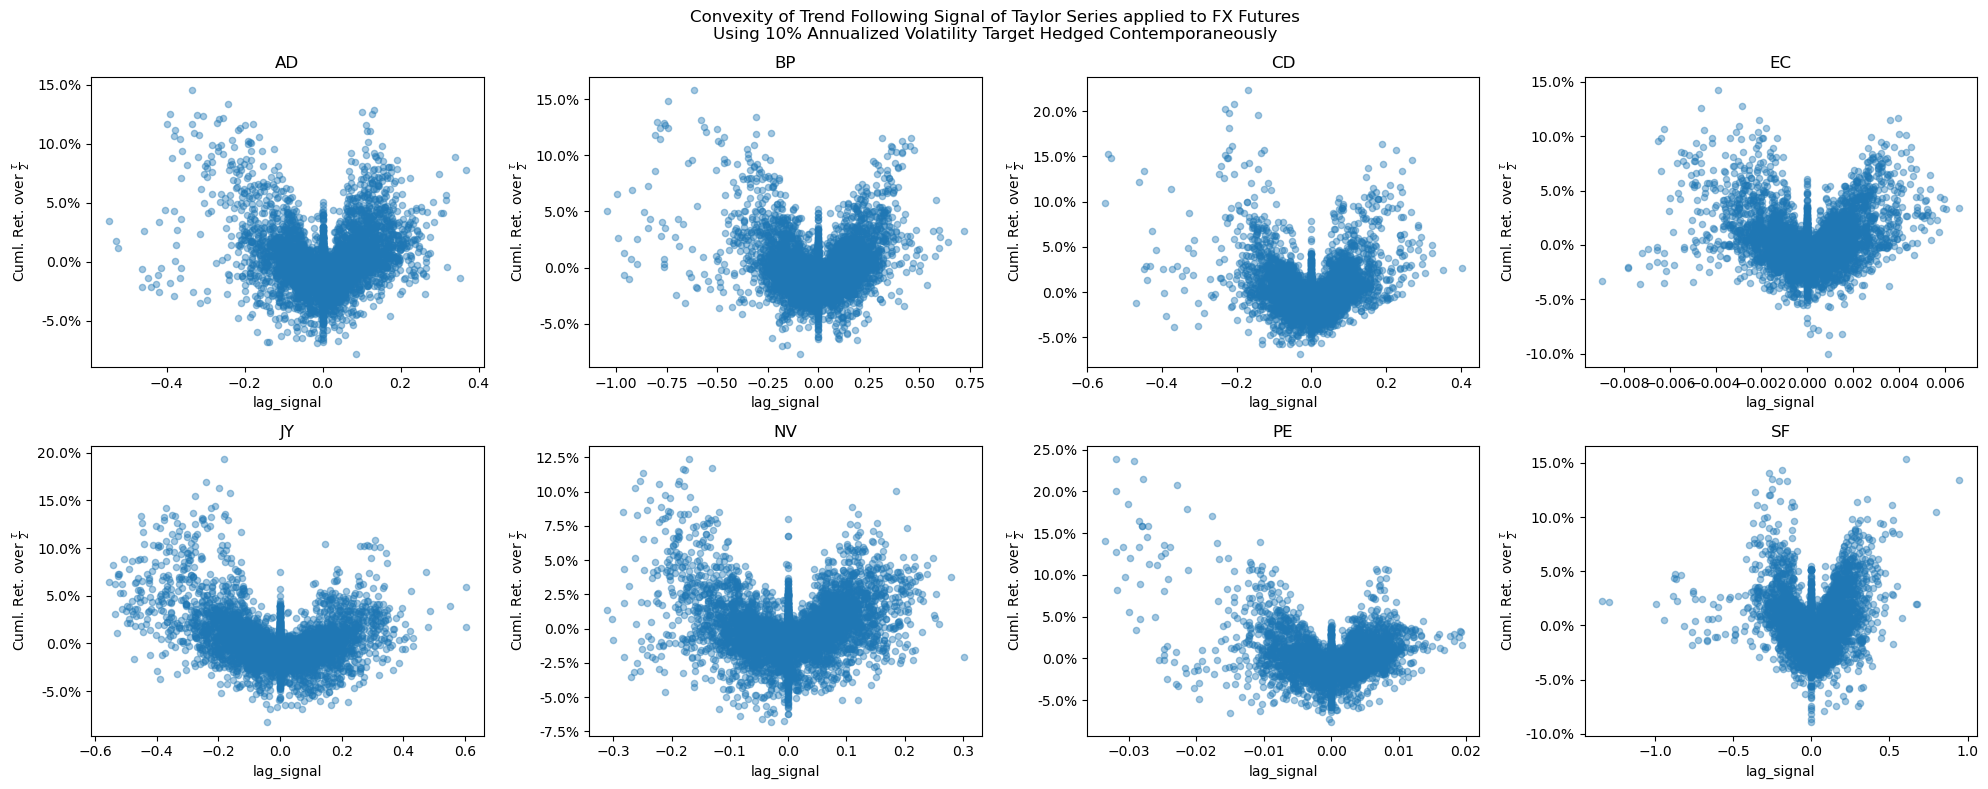

In [175]:
roots     = df_combined.root.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = 4, nrows = 2, figsize = (20,8))

for ax, root in zip(axes.flatten(), roots):

    (df_combined
        .loc[lambda x: x.root == root]
        .assign(year = lambda x: pd.to_datetime(x.date).dt.year)
        .loc[lambda x: x.year != x.year.min()]
        .plot(
            ax     = ax,
            alpha  = 0.4,
            kind   = "scatter", 
            x      = "lag_signal", 
            y      = "cuml_rtn",
            title  = root,
            ylabel = r"Cuml. Ret. over $\frac{\tau}{2}$"))

    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.1%}"))

fig.suptitle("Convexity of Trend Following Signal of Taylor Series applied to FX Futures\nUsing 10% Annualized Volatility Target Hedged Contemporaneously")
plt.tight_layout()

In [180]:
df_port = (df_combined
    .rename(columns = {"root": ""})
    .pivot(index = "date", columns = "", values = "vol_rtn")
    .fillna(0)
    .assign(Average = lambda x: x.mean(axis = 1))
    .apply(lambda x: np.cumprod(1 + x)))

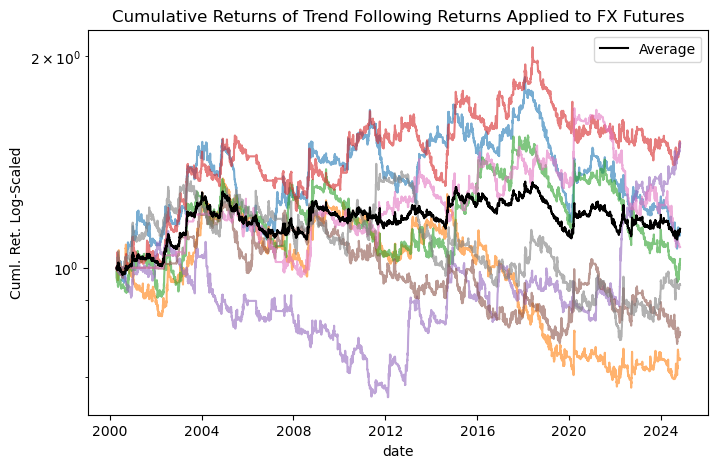

In [189]:
fig, axes = plt.subplots(figsize = (8,5))
(df_port
    .drop(columns = ["Average"])
    .plot(ax = axes, legend = False, alpha = 0.6, logy = True))

(df_port
    [["Average"]]
    .plot(ax = axes, color = "black", logy = True))

axes.set_ylabel("Cuml. Ret. Log-Scaled")
axes.set_title("Cumulative Returns of Trend Following Returns Applied to FX Futures")
plt.show()